In [13]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

ds = load_dataset("sidSircar2103/kaggle_air_quality_dataset")
os.makedirs("charts", exist_ok=True)
sns.set_theme(style="whitegrid")

In [7]:
df = ds['train'].to_pandas()

print(df.info())
print(df.head())
df.describe().T

print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate RecordIDs:", df["RecordID"].duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5811 entries, 0 to 5810
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   RecordID             5811 non-null   int64  
 1   AQI                  5811 non-null   float64
 2   PM10                 5811 non-null   float64
 3   PM2_5                5811 non-null   float64
 4   NO2                  5811 non-null   float64
 5   SO2                  5811 non-null   float64
 6   O3                   5811 non-null   float64
 7   Temperature          5811 non-null   float64
 8   Humidity             5811 non-null   float64
 9   WindSpeed            5811 non-null   float64
 10  RespiratoryCases     5811 non-null   int64  
 11  CardiovascularCases  5811 non-null   int64  
 12  HospitalAdmissions   5811 non-null   int64  
 13  HealthImpactScore    5811 non-null   float64
 14  HealthImpactClass    5811 non-null   float64
dtypes: float64(11), int64(4)
memory usage:

In [ ]:
start = len(df) 
df["HealthImpactClass"] = df["HealthImpactClass"].round().astype(int)
print(f"{start} rows -> {len(df)} rows")

pollutants = ["PM10", "PM2_5", "NO2", "SO2", "O3"]
weather = ["Temperature", "Humidity", "WindSpeed"]
health_risk = ["RespiratoryCases", "CardiovascularCases", "HospitalAdmissions", "HealthImpactScore"]

5811 rows -> 5811 rows


In [14]:
bands = [0, 50, 100, 150, 200, 300, 500]
names = ["Good", "Moderate", "Unhealthy for sensitive", "Unhealthy", "Very unhealthy", "Hazardous"]
df["AQI_Category"] = pd.cut(df["AQI"], bins=bands, labels=names, include_lowest=True)
df["AQI_Category"].value_counts().reindex(names)

AQI_Category
Good                        605
Moderate                    589
Unhealthy for sensitive     583
Unhealthy                   586
Very unhealthy             1128
Hazardous                  2320
Name: count, dtype: int64

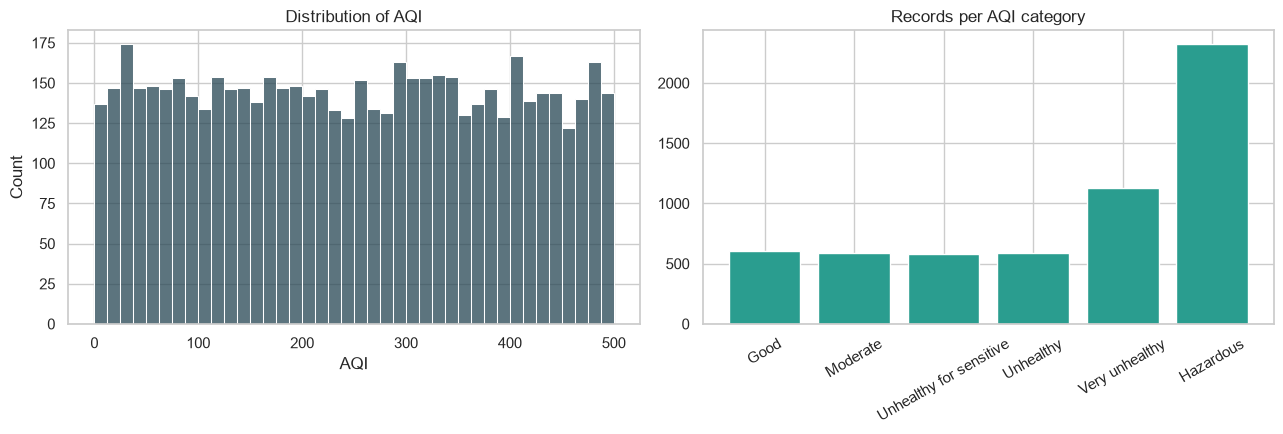

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df["AQI"], bins=40, color="#264653", ax=axes[0])
axes[0].set_title("Distribution of AQI")

counts = df["AQI_Category"].value_counts().reindex(names)
axes[1].bar(counts.index, counts.values, color="#2a9d8f")
axes[1].set_title("Records per AQI category")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("charts/aqi_overview.png", dpi=150)
plt.show()

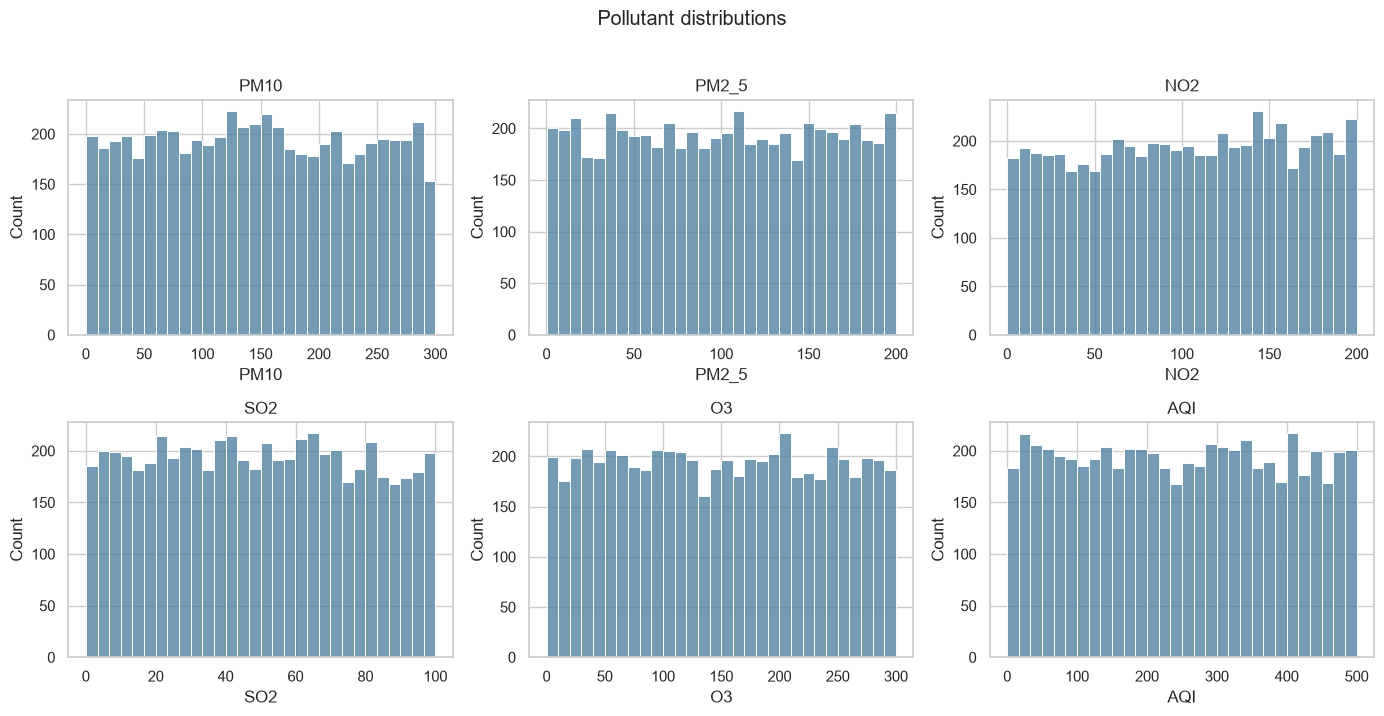

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, pollutants + ["AQI"]):
    sns.histplot(df[col], bins=30, ax=ax, color="#457b9d")
    ax.set_title(col)
plt.suptitle("Pollutant distributions", y=1.02)
plt.tight_layout()
plt.savefig("charts/pollutant_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

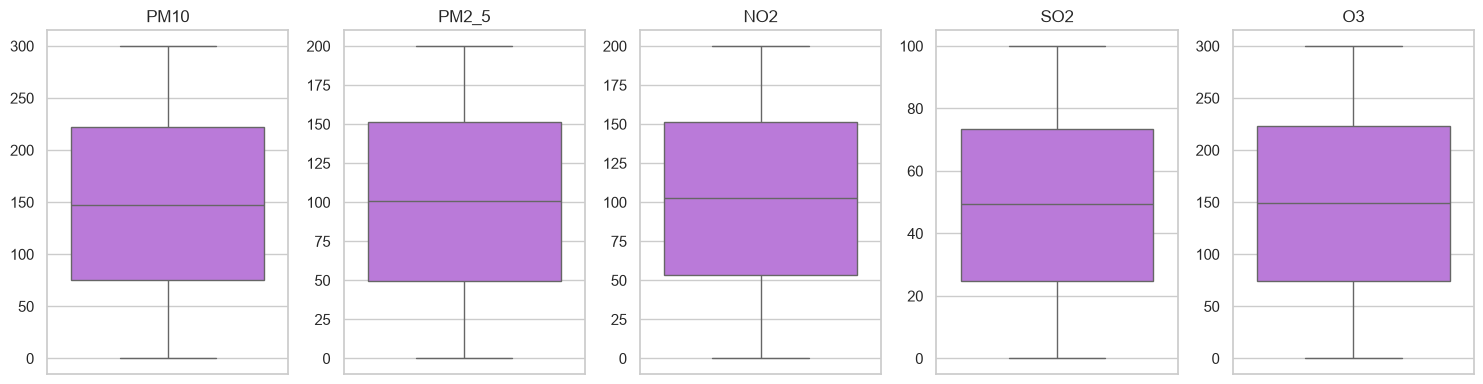

Outliers per column (IQR rule):
PM10           0
PM2_5          0
NO2            0
SO2            0
O3             0
Temperature    0
Humidity       0
WindSpeed      0
dtype: int64


In [41]:
fig, axes = plt.subplots(1, 5, figsize=(15, 4))
for ax, col in zip(axes, pollutants):
    sns.boxplot(y=df[col], ax=ax, color="#bf6ae9")
    ax.set_title(col)
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

q1 = df[pollutants + weather].quantile(0.25)
q3 = df[pollutants + weather].quantile(0.75)
iqr = q3 - q1
outliers = ((df[pollutants + weather] < q1 - 1.5 * iqr) | (df[pollutants + weather] > q3 + 1.5 * iqr)).sum()
print("Outliers per column (IQR rule):")
print(outliers)

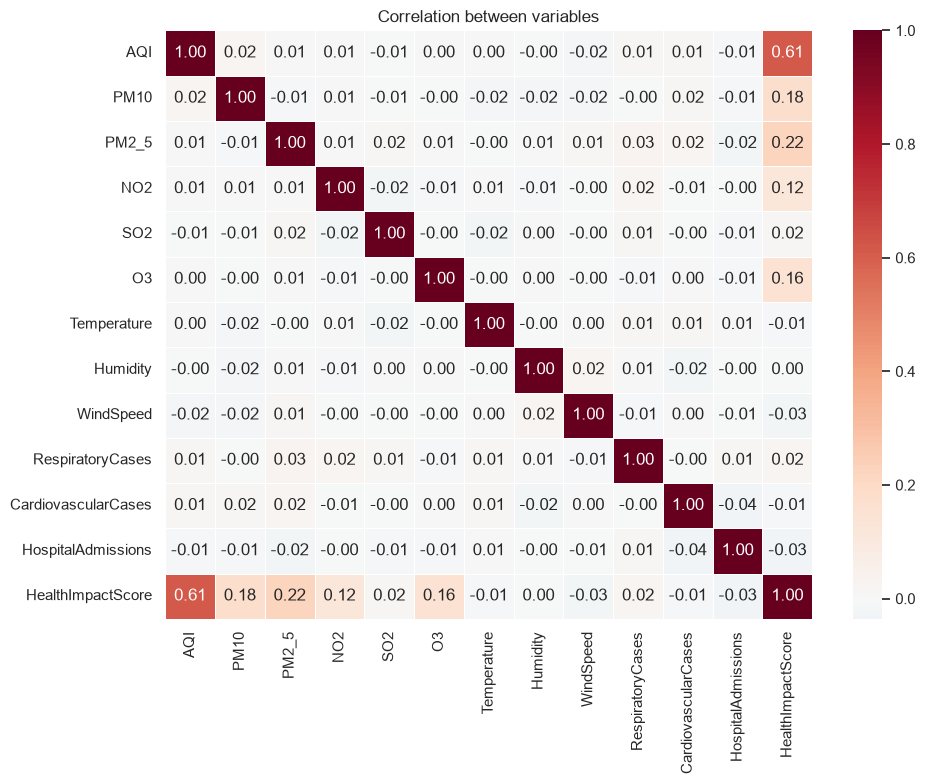

In [18]:
num_cols = ["AQI"] + pollutants + weather + health_risk
corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, linewidths=0.5)
plt.title("Correlation between variables")
plt.tight_layout()
plt.savefig("charts/correlation_heatmap.png", dpi=150)
plt.show()

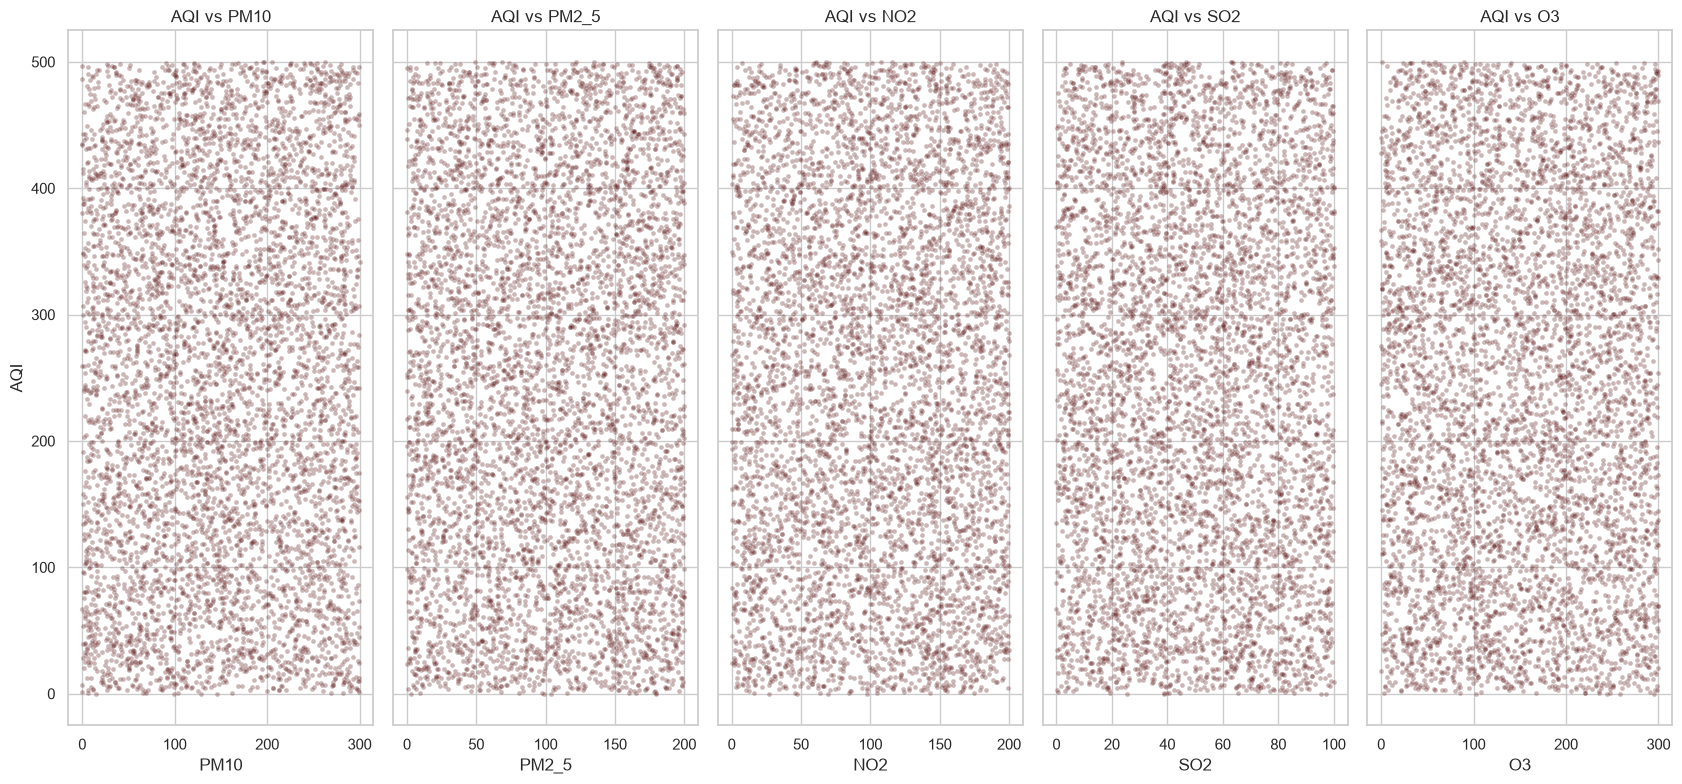

In [36]:
fig, axes = plt.subplots(1, 5, figsize=(17, 8), sharey=True)
for ax, col in zip(axes, pollutants):
    sns.scatterplot(data=df, x=col, y="AQI", alpha=0.3, s=12, ax=ax, color="#560C0C")
    ax.set_title(f"AQI vs {col}")
plt.tight_layout()
plt.savefig("charts/pollutants_vs_aqi.png", dpi=150)
plt.show()

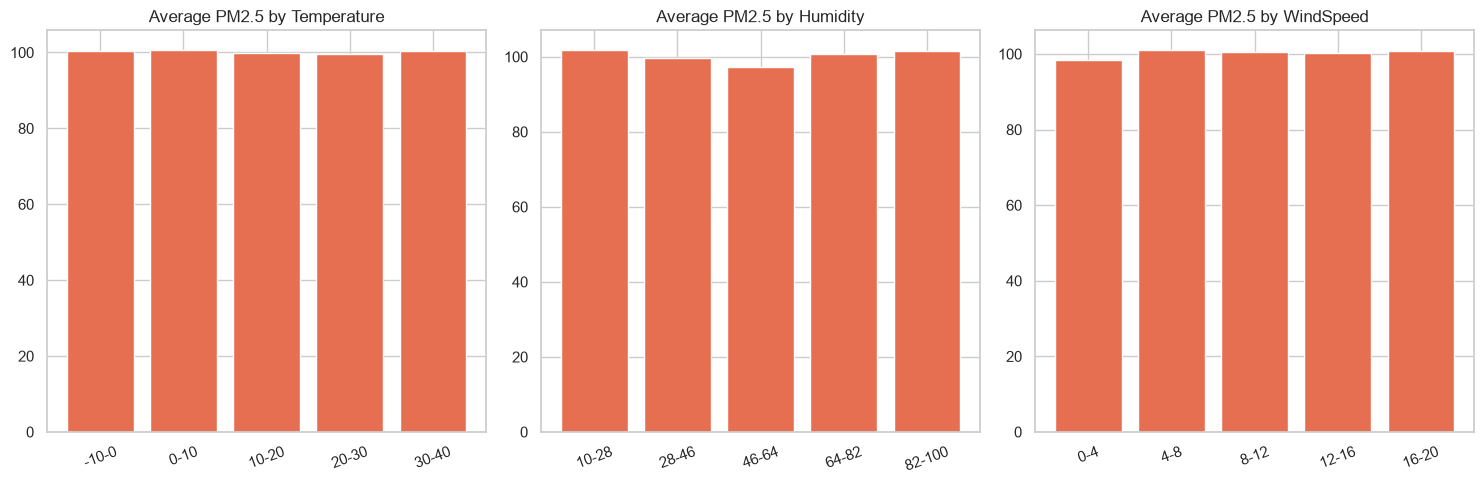

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, weather):
    groups = pd.qcut(df[col], 5)
    avg = df.groupby(groups, observed=True)["PM2_5"].mean()
    ax.bar(range(5), avg.values, color="#e76f51")
    ax.set_xticks(range(5))
    ax.set_xticklabels([f"{i.left:.0f}-{i.right:.0f}" for i in avg.index], rotation=20)
    ax.set_title(f"Average PM2.5 by {col}")
plt.tight_layout()
plt.savefig("charts/weather_vs_pm25.png", dpi=150)
plt.show()

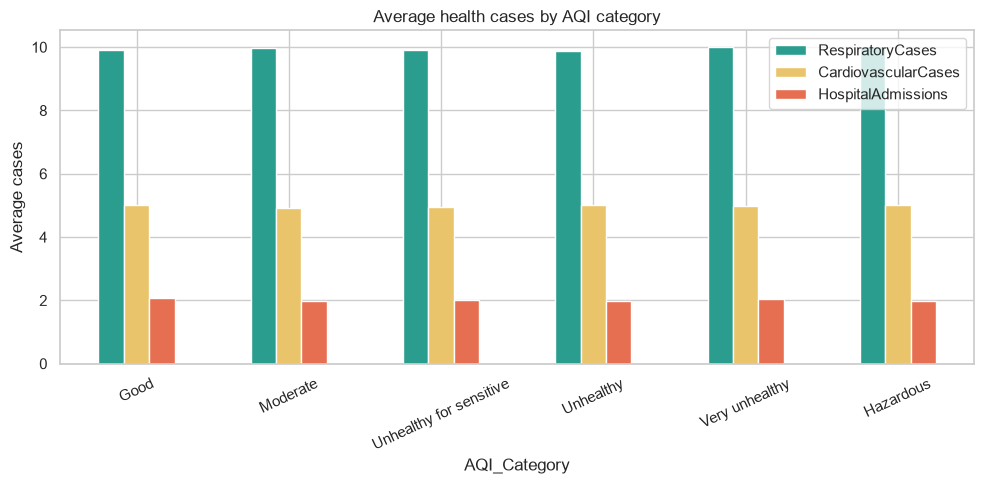

,RespiratoryCases,CardiovascularCases,HospitalAdmissions
AQI_Category,,,
Good,9.90,5.00,2.07
Moderate,9.96,4.93,1.99
Unhealthy for sensitive,9.92,4.96,2.00
Unhealthy,9.87,5.02,1.96
Very unhealthy,10.00,4.98,2.04
Hazardous,10.02,5.01,1.98


In [25]:
by_category = df.groupby("AQI_Category", observed=True)[["RespiratoryCases", "CardiovascularCases", "HospitalAdmissions"]].mean()
by_category = by_category.reindex([n for n in names if n in by_category.index])

by_category.plot(kind="bar", figsize=(10, 5), color=["#2a9d8f", "#e9c46a", "#e76f51"])
plt.title("Average health cases by AQI category")
plt.ylabel("Average cases")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig("charts/health_by_aqi.png", dpi=150)
plt.show()
by_category.round(2)

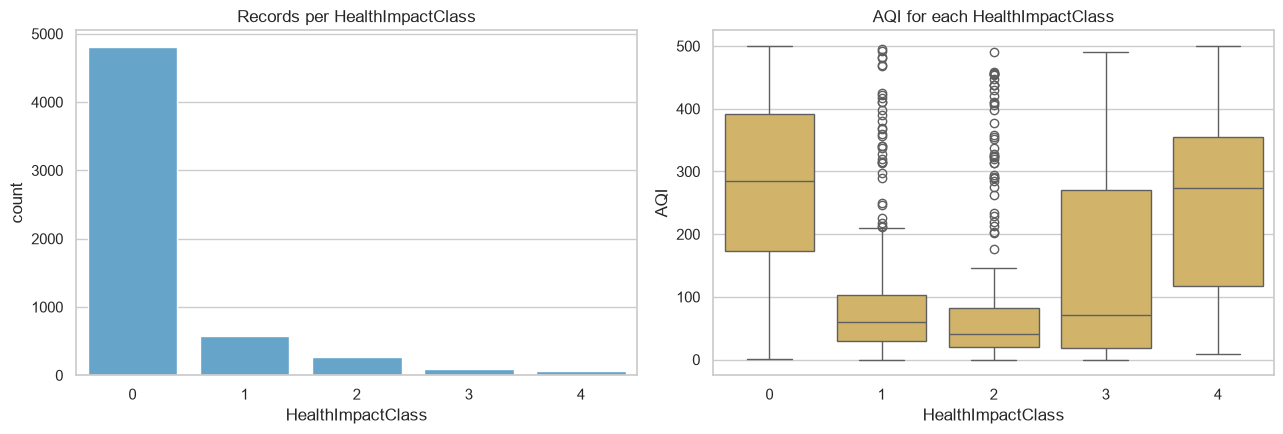

,count,mean
HealthImpactClass,,
0,4808,98.5
1,579,73.4
2,273,62.0
3,95,68.9
4,56,93.8


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.countplot(data=df, x="HealthImpactClass", color="#55a8db", ax=axes[0])
axes[0].set_title("Records per HealthImpactClass")

sns.boxplot(data=df, x="HealthImpactClass", y="AQI", color="#e2bb59", ax=axes[1])
axes[1].set_title("AQI for each HealthImpactClass")

plt.tight_layout()
plt.savefig("charts/health_impact_class.png", dpi=150)
plt.show()


df.groupby("HealthImpactClass")["HealthImpactScore"].agg(["count", "mean"]).round(1)

## Limitations
- Correlation is not causation. These charts show what moves together, not what causes what.
- The dataset card has no description, so units, location, time period and the meaning of `HealthImpactClass` are unknown.
- There is no date or city column, so unable to look at trends over time or compare places.

In [37]:
aqi_corr = corr["AQI"].drop("AQI")
top_aqi = aqi_corr.reindex(aqi_corr.abs().sort_values(ascending=False).index)[:3]

score_corr = corr["HealthImpactScore"].drop("HealthImpactScore")
top_score = score_corr.reindex(score_corr.abs().sort_values(ascending=False).index)[:3]

unhealthy = df["AQI"] > 100
worst = by_cat["HospitalAdmissions"].idxmax()

print(f"=> {len(df):,} records; average AQI is {df['AQI'].mean():.0f} (median {df['AQI'].median():.0f}).")
print(f"=> {unhealthy.mean() * 100:.1f}% of records have AQI above 100 (unhealthy for sensitive groups or worse).")
print("=> Variables most correlated with AQI: " + ", ".join(f"{k} ({v:+.2f})" for k, v in top_aqi.items()))
print("=> Variables most correlated with HealthImpactScore: " + ", ".join(f"{k} ({v:+.2f})" for k, v in top_score.items()))
print(f"=> Highest average hospital admissions: '{worst}' category ({by_cat.loc[worst, 'HospitalAdmissions']:.1f}).")

=> 5,811 records; average AQI is 248 (median 249).
=> 79.5% of records have AQI above 100 (unhealthy for sensitive groups or worse).
=> Variables most correlated with AQI: HealthImpactScore (+0.61), PM10 (+0.02), WindSpeed (-0.02)
=> Variables most correlated with HealthImpactScore: AQI (+0.61), PM2_5 (+0.22), PM10 (+0.18)
=> Highest average hospital admissions: 'Good' category (2.1).
